In [2]:
import os, random, time
os.environ['CUDA_VISIBLE_DEVICES'] = "0"
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim

import numpy as np, pandas as pd, seaborn as sns
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torch.amp import GradScaler, autocast
from torchvision.transforms import v2
import torchvision.datasets as datasets
from matplotlib import pyplot as plt
from pathlib import Path
from PIL import Image
from transformers import AutoModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings; warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [5]:
DATA_DIR   = Path('./medium_dataset/train_set')
TEST_DIR   = Path('./medium_dataset/test_set')
OUTPUT_DIR = Path('./output_dinov3_finetune')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES     = ['excavator', 'train', 'train_tracks', 'workers']
NUM_CLASSES = 4
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
IM_SIZE     = 518          # DINOv3 ViT-L default input size
BATCH_SIZE  = 8            # ViT-L is large, keep batch small
VAL_SPLIT   = 0.15         # 15% validation from training data
TEST_SPLIT  = 0.15         # 15% labeled test for internal evaluation
MODEL_NAME  = 'facebook/dinov3-vitl16-pretrain-lvd1689m'

print(f'Output dir: {OUTPUT_DIR}')

Output dir: output_dinov3_finetune


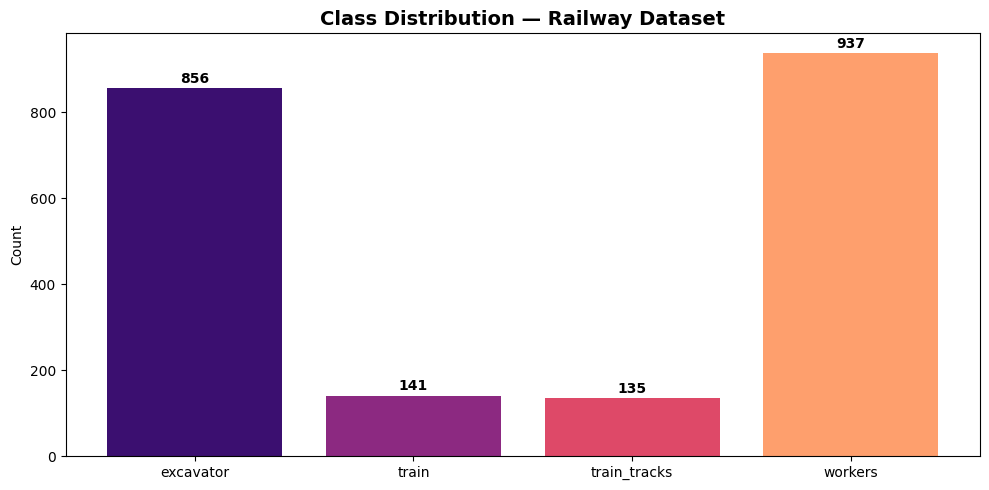

In [6]:
# Class distribution
_tmp = datasets.ImageFolder(DATA_DIR)
counts = Counter(_tmp.targets)
cls_counts = [counts[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 5))
colors = sns.color_palette('magma', NUM_CLASSES)
bars = plt.bar(CLASSES, cls_counts, color=colors)
for bar, cnt in zip(bars, cls_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(cnt), ha='center', va='bottom', fontweight='bold')
plt.title('Class Distribution — Railway Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Count'); plt.tight_layout(); plt.show()

In [9]:
class FocalLoss(nn.Module):
    """Focal Loss: down-weights easy correct predictions, focuses gradient on hard ones."""
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

In [10]:
# ── Transforms ───────────────────────────────────────────────────────────────
train_tf = v2.Compose([
    v2.RandomResizedCrop(IM_SIZE, scale=(0.2, 1.0)),   # forces tiny-object views
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(p=0.2),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    v2.RandomGrayscale(p=0.05),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])
val_tf = v2.Compose([
    v2.Resize(IM_SIZE + 32),
    v2.CenterCrop(IM_SIZE),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=MEAN, std=STD),
])

def _tf(*ops):
    return v2.Compose([*ops, v2.ToImage(), v2.ToDtype(torch.float32, scale=True), v2.Normalize(MEAN, STD)])

# 10 TTA views per image — averaging over these reduces variance on hard borderline cases
TTA_TRANSFORMS = [
    _tf(v2.Resize(IM_SIZE + 32), v2.CenterCrop(IM_SIZE)),                                    # 1. original
    _tf(v2.Resize(IM_SIZE + 32), v2.CenterCrop(IM_SIZE), v2.RandomHorizontalFlip(p=1.0)),    # 2. hflip
    _tf(v2.Resize(IM_SIZE + 32), v2.CenterCrop(IM_SIZE), v2.RandomVerticalFlip(p=1.0)),      # 3. vflip
    _tf(v2.Resize(IM_SIZE + 32), v2.CenterCrop(IM_SIZE), v2.RandomHorizontalFlip(p=1.0),
        v2.RandomVerticalFlip(p=1.0)),                                                         # 4. hflip+vflip
    _tf(v2.RandomResizedCrop(IM_SIZE, scale=(0.85, 1.0))),                                    # 5. tight crop
    _tf(v2.RandomResizedCrop(IM_SIZE, scale=(0.85, 1.0)), v2.RandomHorizontalFlip(p=1.0)),   # 6. tight crop + hflip
    _tf(v2.RandomResizedCrop(IM_SIZE, scale=(0.65, 0.85))),                                   # 7. zoom-in crop
    _tf(v2.RandomResizedCrop(IM_SIZE, scale=(0.65, 0.85)), v2.RandomHorizontalFlip(p=1.0)),  # 8. zoom-in + hflip
    _tf(v2.Resize(IM_SIZE + 32), v2.CenterCrop(IM_SIZE), v2.RandomRotation((90, 90))),       # 9. rot90
    _tf(v2.Resize(IM_SIZE + 32), v2.CenterCrop(IM_SIZE), v2.RandomRotation((-90, -90))),     # 10. rot270
]
N_TTA = len(TTA_TRANSFORMS)
print(f'TTA views: {N_TTA}')

# ── Stratified 3-way split (train / val / labeled_test) ──────────────────────
base_ds = datasets.ImageFolder(DATA_DIR)
n_total = len(base_ds)
indices = list(range(n_total))
targets = base_ds.targets

tr_val_idx, test_idx = train_test_split(
    indices, test_size=TEST_SPLIT,
    stratify=[targets[i] for i in indices], random_state=SEED
)
tr_idx, val_idx = train_test_split(
    tr_val_idx, test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=[targets[i] for i in tr_val_idx], random_state=SEED
)

print(f'Total: {n_total}  Train: {len(tr_idx)}  Val: {len(val_idx)}  Labeled test: {len(test_idx)}')
for name, idx in [('train', tr_idx), ('val', val_idx), ('labeled_test', test_idx)]:
    c = Counter(targets[i] for i in idx)
    print(f'  {name}: { {CLASSES[j]: c[j] for j in range(NUM_CLASSES)} }')

train_ds        = Subset(datasets.ImageFolder(DATA_DIR, transform=train_tf), tr_idx)
val_ds          = Subset(datasets.ImageFolder(DATA_DIR, transform=val_tf),   val_idx)
labeled_test_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=val_tf),   test_idx)

class_counts = [0] * NUM_CLASSES
for i in tr_idx:
    class_counts[targets[i]] += 1
weights_arr  = np.array([1.0 / c for c in class_counts], dtype=np.float32)
weights_arr /= weights_arr.sum()
sample_w     = [weights_arr[targets[i]] for i in tr_idx]
sampler      = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)
class_weights = torch.tensor(weights_arr, dtype=torch.float32).to(device)

train_loader        = DataLoader(train_ds,        batch_size=BATCH_SIZE, sampler=sampler,
                                 num_workers=4, pin_memory=True)
val_loader          = DataLoader(val_ds,          batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=4, pin_memory=True)
labeled_test_loader = DataLoader(labeled_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=4, pin_memory=True)

TTA views: 10
Total: 2069  Train: 1447  Val: 311  Labeled test: 311
  train: {'excavator': 598, 'train': 99, 'train_tracks': 95, 'workers': 655}
  val: {'excavator': 129, 'train': 21, 'train_tracks': 20, 'workers': 141}
  labeled_test: {'excavator': 129, 'train': 21, 'train_tracks': 20, 'workers': 141}


In [11]:
class TTALabeledDataset(Dataset):
    """Labeled subset with N TTA views per image.
    Returns (views [N_TTA, C, H, W], label).
    """
    def __init__(self, base_ds, indices, tta_transforms):
        self.samples    = base_ds.samples   # list of (path, label)
        self.indices    = indices
        self.transforms = tta_transforms

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        path, label = self.samples[self.indices[i]]
        img = Image.open(path).convert('RGB')
        views = torch.stack([tf(img) for tf in self.transforms])
        return views, label


class TTAUnlabeledDataset(Dataset):
    """Unlabeled test images with N TTA views per image.
    Returns (views [N_TTA, C, H, W], filename_stem).
    """
    def __init__(self, test_dir: Path, tta_transforms):
        self.files      = sorted([f for f in test_dir.glob('*')
                                  if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
        self.transforms = tta_transforms
        print(f'Unlabeled test images: {len(self.files)}')

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        img = Image.open(self.files[i]).convert('RGB')
        views = torch.stack([tf(img) for tf in self.transforms])
        return views, self.files[i].name


tta_labeled_loader   = DataLoader(TTALabeledDataset(base_ds, test_idx, TTA_TRANSFORMS),
                                  batch_size=4, shuffle=False, num_workers=2)
tta_unlabeled_loader = DataLoader(TTAUnlabeledDataset(TEST_DIR, TTA_TRANSFORMS),
                                  batch_size=4, shuffle=False, num_workers=2)

Unlabeled test images: 229


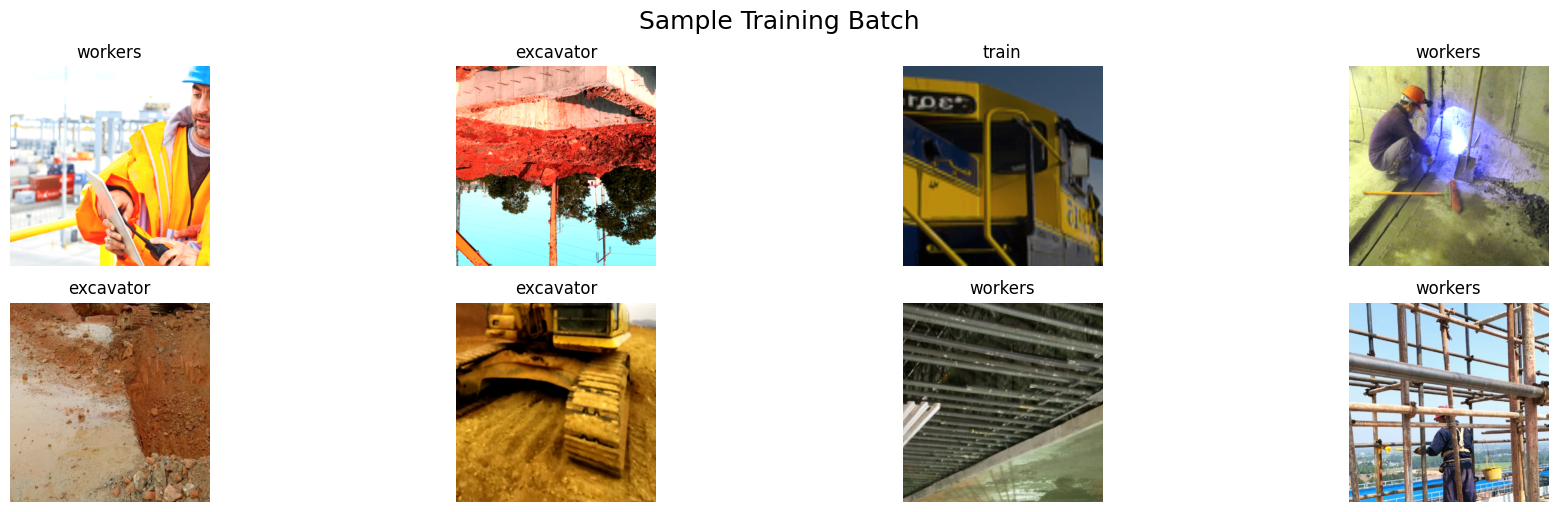

In [12]:
# Sample training batch visualization
def unnormalize(img, mean, std):
    img = img.clone().permute(1, 2, 0)
    img = img * torch.tensor(std) + torch.tensor(mean)
    return img.clamp(0, 1)

batch_images, batch_labels = next(iter(train_loader))
plt.figure(figsize=(18, 10))
plt.suptitle('Sample Training Batch', fontsize=18)
for i in range(min(16, len(batch_images))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(unnormalize(batch_images[i].cpu(), MEAN, STD).numpy())
    plt.title(CLASSES[batch_labels[i].item()])
    plt.axis('off')
plt.tight_layout(); plt.show()

In [13]:
# ── DINOv3 model ─────────────────────────────────────────────────────────────
def get_dinov3_model(num_classes=4):
    backbone = AutoModel.from_pretrained(MODEL_NAME)

    # Freeze entire backbone for Stage 1
    for p in backbone.parameters():
        p.requires_grad = False

    backbone.gradient_checkpointing_enable()   

    # 4-class classification head attached directly on the backbone object
    in_features = 1024   # ViT-L CLS token dim
    backbone.head = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.GELU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes),
    )
    return backbone.to(device)


def dino_forward(model, images):
    """CLS token from last hidden state → classification head → logits."""
    outputs   = model(pixel_values=images)
    cls_token = outputs.last_hidden_state[:, 0]   # shape: [B, 1024]
    return model.head(cls_token)

In [14]:
def trainer(model, train_loader, val_loader, num_epochs, class_weights, device,
            save_path='dinov3_best.pth', patience=7, lr=1e-3, weight_decay=0.01,
            focal_gamma=2.0):

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = GradScaler('cuda')
    criterion = FocalLoss(gamma=focal_gamma, weight=class_weights)

    best_val_acc = 0.0
    no_improve   = 0
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    train_f1s,    val_f1s    = [], []

    for epoch in range(1, num_epochs + 1):
        # ── Train ───────────────────────────────────────────────
        model.train()
        run_loss = run_correct = run_total = 0
        all_preds_tr, all_labels_tr = [], []
        t0 = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast('cuda'):
                logits = dino_forward(model, images)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()

            run_loss    += loss.item() * images.size(0)
            preds        = logits.argmax(1)
            run_correct += (preds == labels).sum().item()
            run_total   += images.size(0)
            all_preds_tr.extend(preds.cpu().numpy())
            all_labels_tr.extend(labels.cpu().numpy())

        scheduler.step()
        avg_tr_loss = run_loss / run_total
        avg_tr_acc  = run_correct / run_total
        avg_tr_f1   = f1_score(all_labels_tr, all_preds_tr, average='macro', zero_division=0)

        # ── Val ─────────────────────────────────────────────────
        model.eval()
        vl_loss = vl_correct = vl_total = 0
        all_preds_vl, all_labels_vl = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                with autocast('cuda'):
                    logits = dino_forward(model, images)
                    loss   = criterion(logits, labels)
                vl_loss    += loss.item() * images.size(0)
                preds       = logits.argmax(1)
                vl_correct += (preds == labels).sum().item()
                vl_total   += images.size(0)
                all_preds_vl.extend(preds.cpu().numpy())
                all_labels_vl.extend(labels.cpu().numpy())

        avg_vl_loss = vl_loss / vl_total
        avg_vl_acc  = vl_correct / vl_total
        avg_vl_f1   = f1_score(all_labels_vl, all_preds_vl, average='macro', zero_division=0)

        train_losses.append(avg_tr_loss); val_losses.append(avg_vl_loss)
        train_accs.append(avg_tr_acc);    val_accs.append(avg_vl_acc)
        train_f1s.append(avg_tr_f1);      val_f1s.append(avg_vl_f1)

        flag = ''
        if avg_vl_acc > best_val_acc:
            best_val_acc = avg_vl_acc
            torch.save(model.state_dict(), OUTPUT_DIR / save_path)
            no_improve = 0; flag = '  ← saved'
        else:
            no_improve += 1

        elapsed = time.time() - t0
        print(f'[{epoch:2d}/{num_epochs}]  '
              f'tr_loss={avg_tr_loss:.4f}  tr_acc={avg_tr_acc:.4f}  '
              f'vl_loss={avg_vl_loss:.4f}  vl_acc={avg_vl_acc:.4f}  '
              f'vl_f1={avg_vl_f1:.4f}  {elapsed:.0f}s{flag}')

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}'); break

    print(f'\nBest val accuracy: {best_val_acc:.4f}')
    return train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s

In [15]:
def plot_metrics(train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s, title=''):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(18, 5))
    if title: plt.suptitle(title, fontsize=14)

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, label='Train'); plt.plot(epochs, val_losses, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accs, label='Train'); plt.plot(epochs, val_accs, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_f1s, label='Train'); plt.plot(epochs, val_f1s, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('F1 (macro)'); plt.title('F1 Score'); plt.legend()

    plt.tight_layout(); plt.show()

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Stage 1 trainable: 527,876 / 303,657,476 total params
[ 1/20]  tr_loss=0.0084  tr_acc=0.8252  vl_loss=0.0008  vl_acc=0.9582  vl_f1=0.9462  33s  ← saved
[ 2/20]  tr_loss=0.0018  tr_acc=0.8943  vl_loss=0.0011  vl_acc=0.9743  vl_f1=0.9602  33s  ← saved
[ 3/20]  tr_loss=0.0029  tr_acc=0.9005  vl_loss=0.0007  vl_acc=0.9711  vl_f1=0.9601  25s
[ 4/20]  tr_loss=0.0013  tr_acc=0.9150  vl_loss=0.0008  vl_acc=0.9711  vl_f1=0.9537  24s
[ 5/20]  tr_loss=0.0010  tr_acc=0.9226  vl_loss=0.0007  vl_acc=0.9678  vl_f1=0.9619  25s
[ 6/20]  tr_loss=0.0019  tr_acc=0.9122  vl_loss=0.0007  vl_acc=0.9775  vl_f1=0.9624  35s  ← saved
[ 7/20]  tr_loss=0.0012  tr_acc=0.9316  vl_loss=0.0014  vl_acc=0.9614  vl_f1=0.9355  25s
[ 8/20]  tr_loss=0.0010  tr_acc=0.9219  vl_loss=0.0010  vl_acc=0.9711  vl_f1=0.9525  25s
[ 9/20]  tr_loss=0.0010  tr_acc=0.9392  vl_loss=0.0008  vl_acc=0.9807  vl_f1=0.9691  36s  ← saved
[10/20]  tr_loss=0.0008  tr_acc=0.9502  vl_loss=0.0006  vl_acc=0.9871  vl_f1=0.9874  32s  ← saved
[11/20]  tr

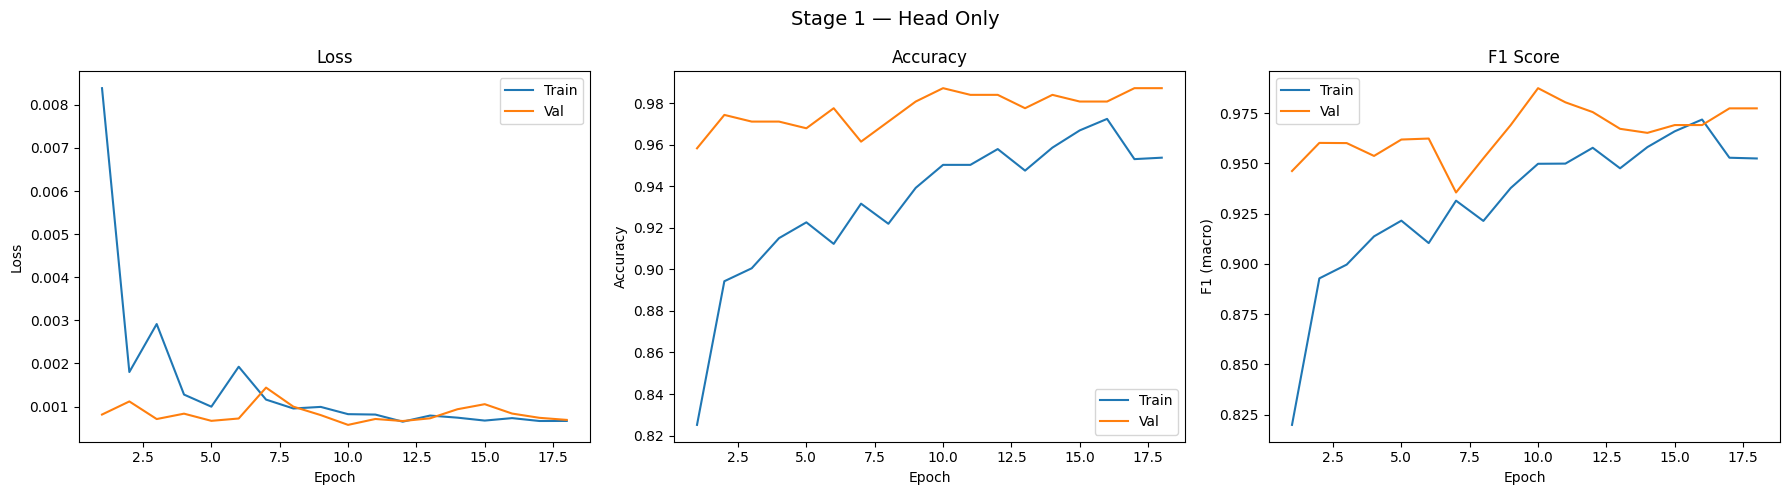

In [16]:
# ── Stage 1: Train classification head only (backbone frozen) ────────────────
model = get_dinov3_model(NUM_CLASSES)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Stage 1 trainable: {trainable:,} / {total:,} total params')

history_s1 = trainer(
    model, train_loader, val_loader,
    num_epochs=20, class_weights=class_weights, device=device,
    save_path='dinov3_s1_best.pth', patience=8, lr=1e-3, focal_gamma=2.0,
)
plot_metrics(*history_s1, title='Stage 1 — Head Only')

Stage 2 trainable params: 76,113,412
[ 1/20]  tr_loss=0.0007  tr_acc=0.9537  vl_loss=0.0008  vl_acc=0.9871  vl_f1=0.9774  49s  ← saved
[ 2/20]  tr_loss=0.0007  tr_acc=0.9675  vl_loss=0.0006  vl_acc=0.9904  vl_f1=0.9841  50s  ← saved
[ 3/20]  tr_loss=0.0007  tr_acc=0.9627  vl_loss=0.0006  vl_acc=0.9871  vl_f1=0.9826  38s
[ 4/20]  tr_loss=0.0008  tr_acc=0.9703  vl_loss=0.0006  vl_acc=0.9904  vl_f1=0.9944  38s
[ 5/20]  tr_loss=0.0006  tr_acc=0.9648  vl_loss=0.0006  vl_acc=0.9936  vl_f1=0.9963  49s  ← saved
[ 6/20]  tr_loss=0.0006  tr_acc=0.9641  vl_loss=0.0005  vl_acc=0.9936  vl_f1=0.9963  39s
[ 7/20]  tr_loss=0.0006  tr_acc=0.9772  vl_loss=0.0006  vl_acc=0.9936  vl_f1=0.9963  38s
[ 8/20]  tr_loss=0.0006  tr_acc=0.9744  vl_loss=0.0006  vl_acc=0.9904  vl_f1=0.9841  39s
[ 9/20]  tr_loss=0.0006  tr_acc=0.9744  vl_loss=0.0006  vl_acc=0.9936  vl_f1=0.9963  39s
[10/20]  tr_loss=0.0006  tr_acc=0.9758  vl_loss=0.0006  vl_acc=0.9936  vl_f1=0.9963  39s
[11/20]  tr_loss=0.0006  tr_acc=0.9696  vl_los

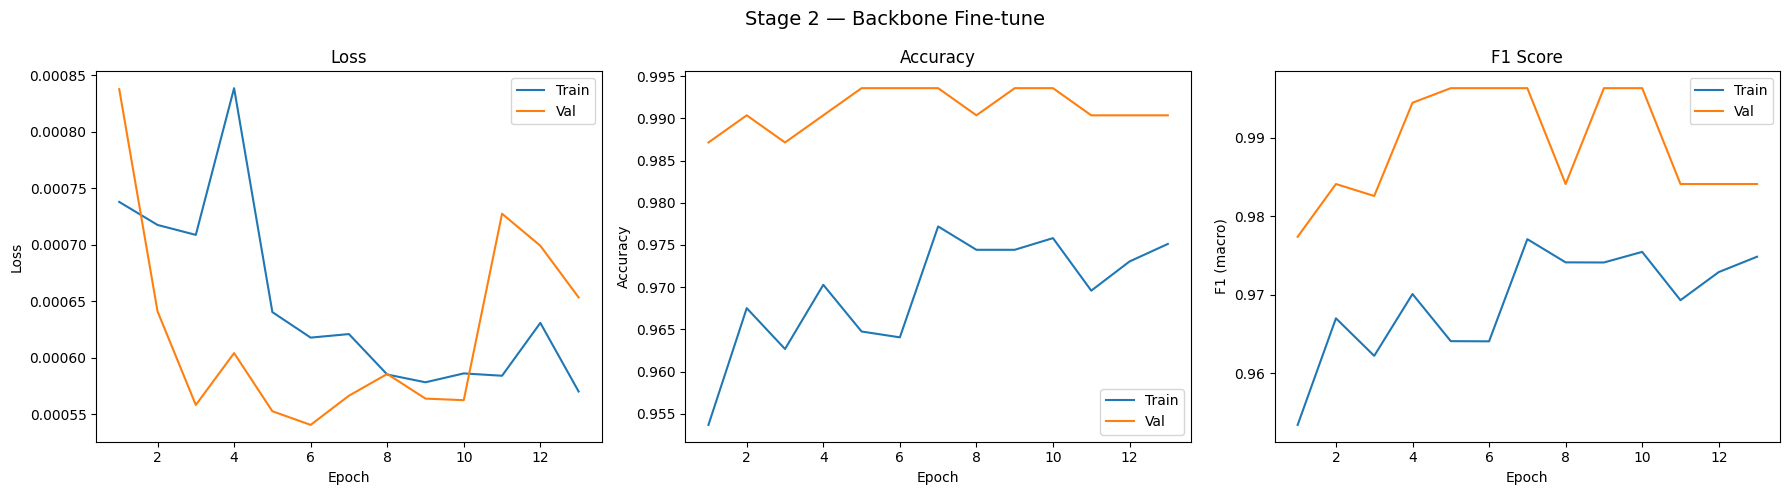

In [17]:
# ── Stage 2: Unfreeze last N transformer blocks + fine-tune at low LR ────────
# DINOv3ViTModel structure: model.layer (ModuleList of 24 blocks), model.norm (final LayerNorm)
model.load_state_dict(torch.load(OUTPUT_DIR / 'dinov3_s1_best.pth', map_location=device))

UNFREEZE_LAST_N = 6
for block in model.layer[-UNFREEZE_LAST_N:]:
    for p in block.parameters():
        p.requires_grad = True
for p in model.norm.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 2 trainable params: {trainable:,}')

history_s2 = trainer(
    model, train_loader, val_loader,
    num_epochs=20, class_weights=class_weights, device=device,
    save_path='dinov3_s2_best.pth', patience=8, lr=1e-5, weight_decay=0.01, focal_gamma=2.0,
)
plot_metrics(*history_s2, title='Stage 2 — Backbone Fine-tune')

Stage 3 trainable params: 151,696,900
[ 1/15]  tr_loss=0.0011  tr_acc=0.9751  vl_loss=0.0006  vl_acc=0.9871  vl_f1=0.9774  56s  ← saved
[ 2/15]  tr_loss=0.0006  tr_acc=0.9710  vl_loss=0.0006  vl_acc=0.9936  vl_f1=0.9963  60s  ← saved
[ 3/15]  tr_loss=0.0006  tr_acc=0.9724  vl_loss=0.0006  vl_acc=0.9871  vl_f1=0.9774  53s
[ 4/15]  tr_loss=0.0006  tr_acc=0.9724  vl_loss=0.0007  vl_acc=0.9871  vl_f1=0.9774  51s
[ 5/15]  tr_loss=0.0005  tr_acc=0.9779  vl_loss=0.0006  vl_acc=0.9871  vl_f1=0.9774  53s
[ 6/15]  tr_loss=0.0006  tr_acc=0.9786  vl_loss=0.0008  vl_acc=0.9871  vl_f1=0.9774  53s
[ 7/15]  tr_loss=0.0006  tr_acc=0.9682  vl_loss=0.0007  vl_acc=0.9871  vl_f1=0.9774  52s
[ 8/15]  tr_loss=0.0006  tr_acc=0.9648  vl_loss=0.0007  vl_acc=0.9807  vl_f1=0.9647  53s
Early stopping at epoch 8

Best val accuracy: 0.9936


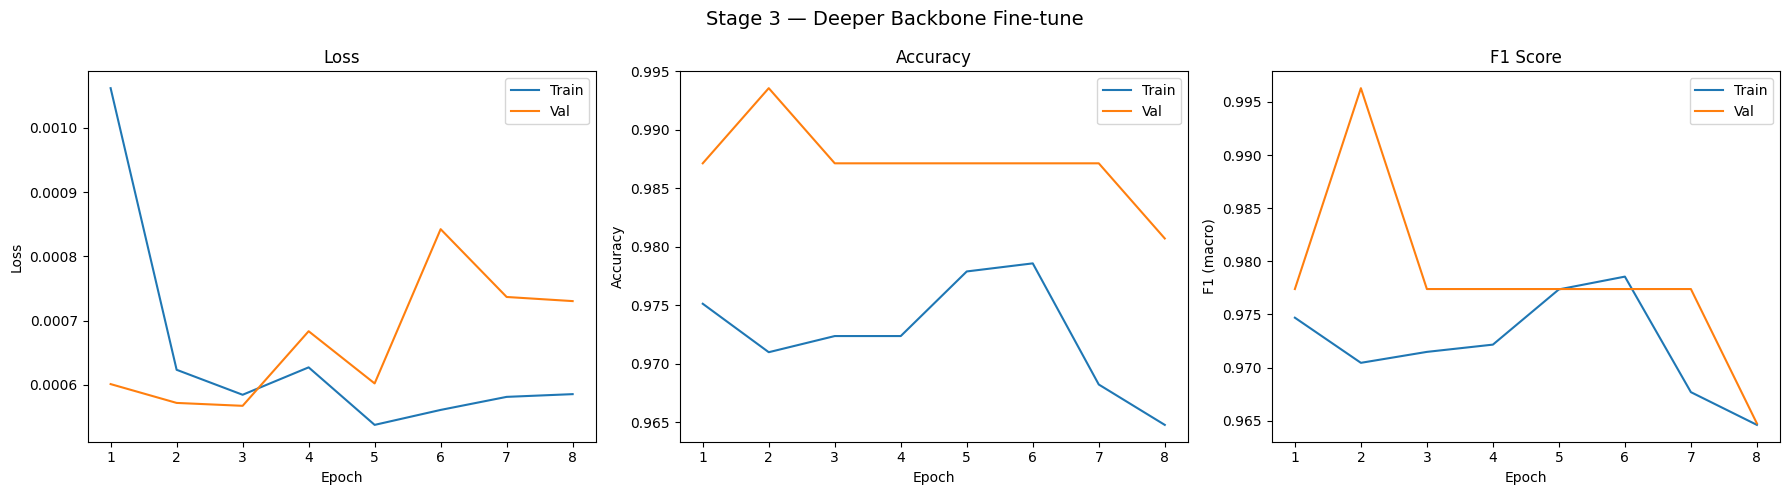

In [18]:
# ── Stage 3: Unfreeze last 12 blocks at very low LR ─────────────────────────
# S2 got the last 6 blocks. S3 opens up 6 more (blocks 12-17) at an even lower LR
# so deeper semantic features fine-tune without destroying earlier S2 gains.
model.load_state_dict(torch.load(OUTPUT_DIR / 'dinov3_s2_best.pth', map_location=device))

UNFREEZE_LAST_N_S3 = 12
for block in model.layer[-UNFREEZE_LAST_N_S3:]:
    for p in block.parameters():
        p.requires_grad = True
for p in model.norm.parameters():
    p.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Stage 3 trainable params: {trainable:,}')

history_s3 = trainer(
    model, train_loader, val_loader,
    num_epochs=15, class_weights=class_weights, device=device,
    save_path='dinov3_s3_best.pth', patience=6, lr=5e-6, weight_decay=0.01, focal_gamma=2.0,
)
plot_metrics(*history_s3, title='Stage 3 — Deeper Backbone Fine-tune')

In [19]:
# ── TTA + Ensemble inference ─────────────────────────────────────────────────
def predict_tta_ensemble(models, tta_loader, has_labels=True):
    """TTA over N_TTA views × len(models) checkpoints — averages all softmax scores.
    models: list of (model, weight) tuples. weights are applied per-model.
    """
    for m, _ in models:
        m.eval()

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for views, targets in tta_loader:
            B = views.size(0)
            probs_sum = torch.zeros(B, NUM_CLASSES, device=device)

            for m, w in models:
                for aug_idx in range(N_TTA):
                    aug_imgs = views[:, aug_idx].to(device)
                    with autocast('cuda'):
                        logits = dino_forward(m, aug_imgs)
                    probs_sum += w * torch.softmax(logits.float(), dim=1)

            batch_preds = probs_sum.argmax(1).cpu().numpy()
            all_preds.extend(batch_preds)
            if has_labels:
                all_targets.extend(targets.numpy())
            else:
                all_targets.extend(targets)

    return all_preds, all_targets

Unlabeled test images: 229


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

=== Labeled Test Set — S2+S3 Ensemble + 10-view TTA ===
              precision    recall  f1-score   support

   excavator       0.99      0.98      0.99       129
       train       1.00      1.00      1.00        21
train_tracks       1.00      1.00      1.00        20
     workers       0.99      0.99      0.99       141

    accuracy                           0.99       311
   macro avg       0.99      0.99      0.99       311
weighted avg       0.99      0.99      0.99       311

Confusion breakdown (row=true, col=predicted):
              excavator  train  train_tracks  workers
excavator           127      0             0        2
train                 0     21             0        0
train_tracks          0      0            20        0
workers               1      0             0      140

Misclassified pairs:
  excavator → workers: 2
  workers → excavator: 1


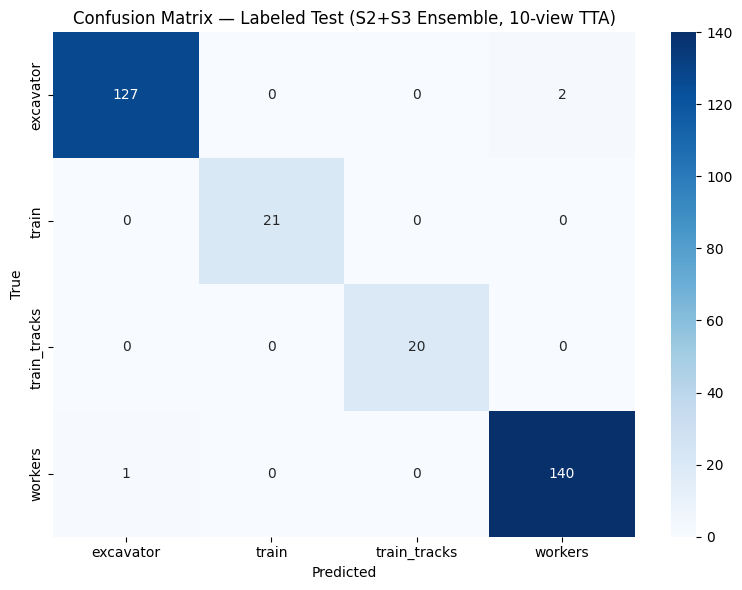

In [20]:
# ── Labeled test set evaluation — S2 + S3 ensemble with TTA ─────────────────
# Rebuild TTA loaders with updated N_TTA
tta_labeled_loader   = DataLoader(TTALabeledDataset(base_ds, test_idx, TTA_TRANSFORMS),
                                  batch_size=4, shuffle=False, num_workers=2)
tta_unlabeled_loader = DataLoader(TTAUnlabeledDataset(TEST_DIR, TTA_TRANSFORMS),
                                  batch_size=4, shuffle=False, num_workers=2)

# Load S2 and S3 checkpoints into separate model instances
model_s2 = get_dinov3_model(NUM_CLASSES)
model_s2.load_state_dict(torch.load(OUTPUT_DIR / 'dinov3_s2_best.pth', map_location=device))

model_s3 = get_dinov3_model(NUM_CLASSES)
model_s3.load_state_dict(torch.load(OUTPUT_DIR / 'dinov3_s3_best.pth', map_location=device))

# Equal weighting — S3 is slightly more fine-tuned; tweak if one is clearly better
ensemble = [(model_s2, 0.4), (model_s3, 0.6)]

all_preds, all_labels = predict_tta_ensemble(ensemble, tta_labeled_loader, has_labels=True)

print('=== Labeled Test Set — S2+S3 Ensemble + 10-view TTA ===')
print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm    = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(cm, index=CLASSES, columns=CLASSES)
print('Confusion breakdown (row=true, col=predicted):')
print(cm_df.to_string())

print('\nMisclassified pairs:')
for ti, tc in enumerate(CLASSES):
    for pi, pc in enumerate(CLASSES):
        if ti != pi and cm[ti, pi] > 0:
            print(f'  {tc} → {pc}: {cm[ti, pi]}')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Labeled Test (S2+S3 Ensemble, 10-view TTA)')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

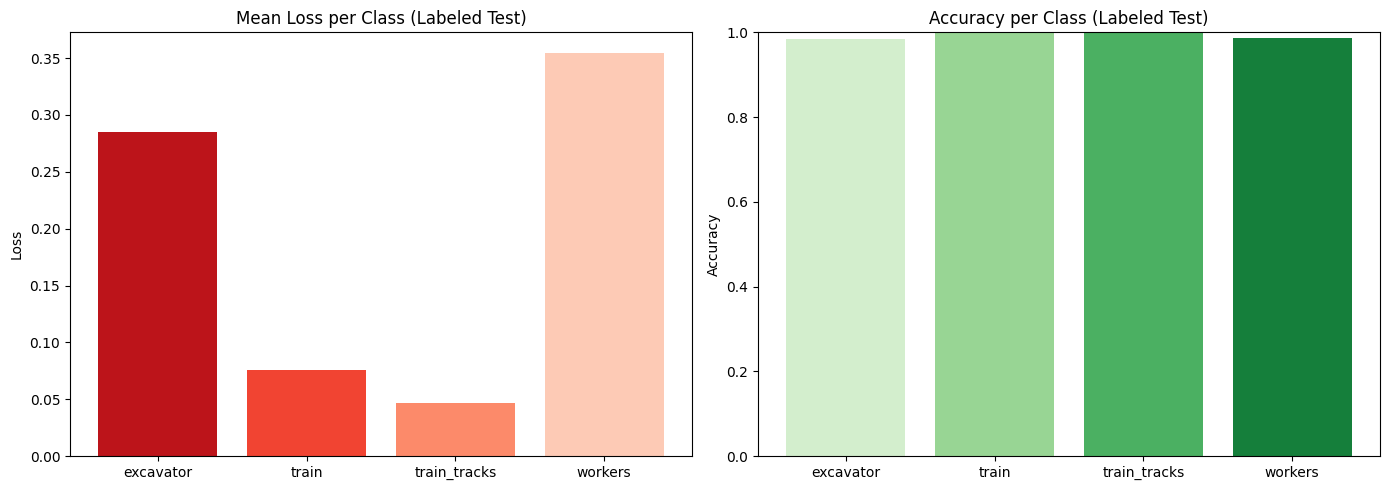


mean loss:
  excavator    0.2847
  train        0.0757
  train_tracks 0.0466
  workers      0.3549


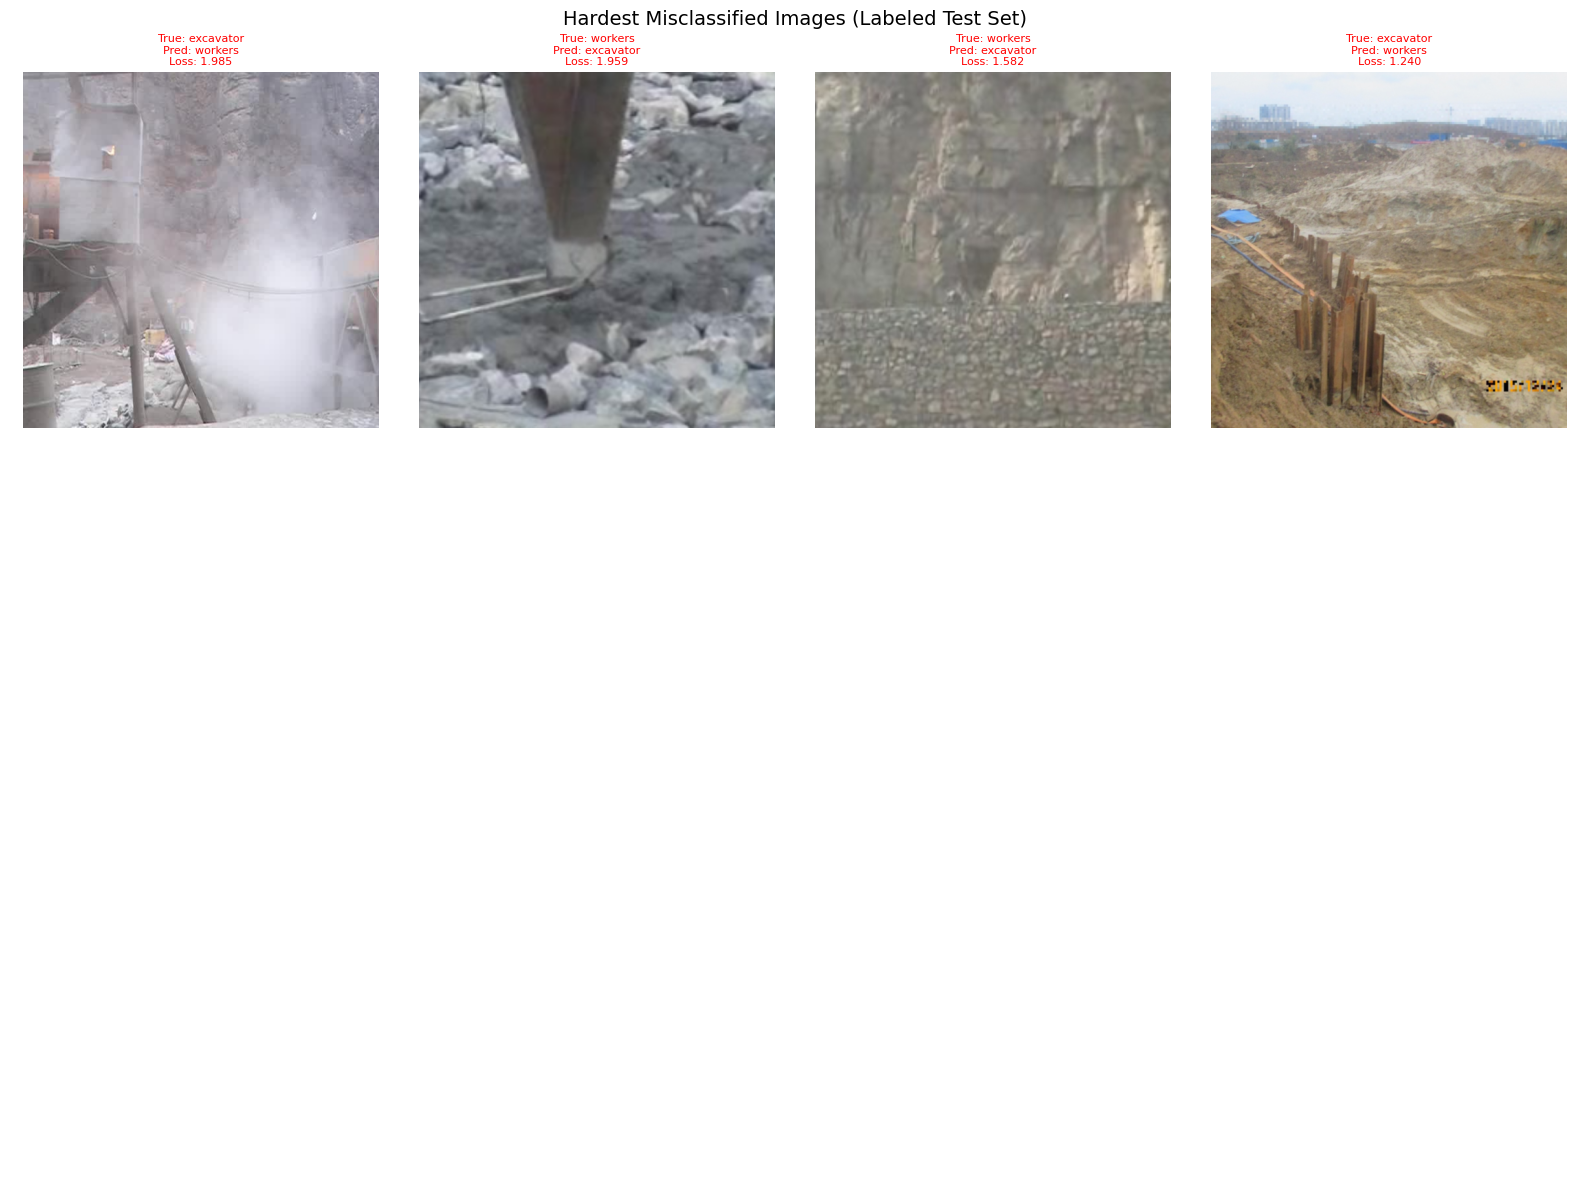

In [23]:
# ── Per-class diagnostic: loss bars + hardest misclassified images ────────────
# Run single-pass eval on labeled test to get per-sample losses and images for visualization
model.eval()
criterion_none = nn.CrossEntropyLoss(reduction='none')

per_class_loss    = [[] for _ in range(NUM_CLASSES)]
per_class_correct = [0] * NUM_CLASSES
per_class_total   = [0] * NUM_CLASSES
hard_samples      = []   # (loss, img_tensor, true_label, pred_label)

with torch.no_grad():
    for images, labels in labeled_test_loader:
        images, labels = images.to(device), labels.to(device)
        with autocast('cuda'):
            logits = dino_forward(model, images)
        losses = criterion_none(logits.float(), labels)
        preds  = logits.argmax(1)

        for img, lbl, pred, loss in zip(images.cpu(), labels.cpu(), preds.cpu(), losses.cpu()):
            l = lbl.item()
            per_class_loss[l].append(loss.item())
            per_class_total[l]   += 1
            per_class_correct[l] += int(pred == lbl)
            if pred != lbl:
                hard_samples.append((loss.item(), img, l, pred.item()))

hard_samples.sort(key=lambda x: -x[0])
cls_mean_loss = [np.mean(per_class_loss[i]) if per_class_loss[i] else 0 for i in range(NUM_CLASSES)]
cls_acc       = [per_class_correct[i] / max(per_class_total[i], 1) for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(CLASSES, cls_mean_loss, color=sns.color_palette('Reds_r', NUM_CLASSES))
axes[0].set_title('Mean Loss per Class (Labeled Test)'); axes[0].set_ylabel('Loss')
axes[1].bar(CLASSES, cls_acc,       color=sns.color_palette('Greens',  NUM_CLASSES))
axes[1].set_title('Accuracy per Class (Labeled Test)'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

print('\nmean loss:')
for cls, ml in zip(CLASSES, cls_mean_loss):
    print(f'  {cls:<12} {ml:.4f}')

n_show = min(12, len(hard_samples))
if n_show > 0:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    plt.suptitle('Hardest Misclassified Images (Labeled Test Set)', fontsize=14)
    for ax, (loss, img, true_lbl, pred_lbl) in zip(axes.flat, hard_samples[:n_show]):
        ax.imshow(unnormalize(img, MEAN, STD).numpy())
        ax.set_title(f'True: {CLASSES[true_lbl]}\nPred: {CLASSES[pred_lbl]}\nLoss: {loss:.3f}',
                     fontsize=8, color='red')
        ax.axis('off')
    for ax in axes.flat[n_show:]: ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No misclassified samples!')

In [24]:
# ── TTA + Ensemble submission on unlabeled test set ──────────────────────────
preds, ids = predict_tta_ensemble(ensemble, tta_unlabeled_loader, has_labels=False)

df = pd.DataFrame({'ID': ids, 'Label': preds})
out_path = OUTPUT_DIR / 'submission_s2s3_ensemble_tta10.csv'
df.to_csv(out_path, index=False)
print(f'Saved {len(df)} predictions → {out_path}')
print(f'Label distribution: {dict(Counter(preds))}')
print(f'Class distribution: { {CLASSES[k]: v for k, v in Counter(preds).items()} }')
print(df.head(10).to_string(index=False))

Saved 229 predictions → output_dinov3_finetune/submission_s2s3_ensemble_tta10.csv
Label distribution: {np.int64(3): 103, np.int64(0): 96, np.int64(1): 15, np.int64(2): 15}
Class distribution: {'workers': 103, 'excavator': 96, 'train': 15, 'train_tracks': 15}
                                                ID  Label
                                       0000199.jpg      3
                                       0000260.jpg      3
000028_jpg.rf.5a5bf143758f11a099e16526e1f856a0.jpg      3
                                       0000349.jpg      3
000034_jpg.rf.f2956d1540dc9ee4b9620b27c98f033f.jpg      3
                                       0000361.jpg      0
                                       0000433.jpg      3
                                       0000555.jpg      3
                                       0000559.jpg      3
                                       0000572.jpg      0
